# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [24]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [25]:
#Type your code here
df= pd.read_csv(r'C:\Users\user\Eksperimen_SML_Meyla Sabrina\houseprices_raw\data.csv')
print("Data berhasil dimuat. ukuran: ", df.shape)

Data berhasil dimuat. ukuran:  (187531, 21)


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [26]:
#Type your code here

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [27]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [28]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [29]:
num_cols= df.select_dtypes(include='number')
cat_cols= df.select_dtypes(include='object')

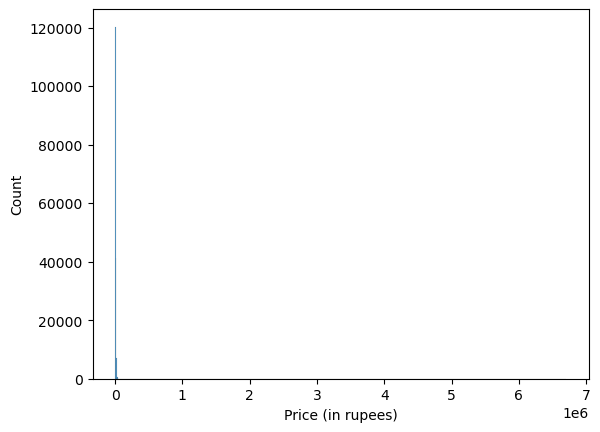

In [30]:
sb.histplot(df['Price (in rupees)'])

plt.show()

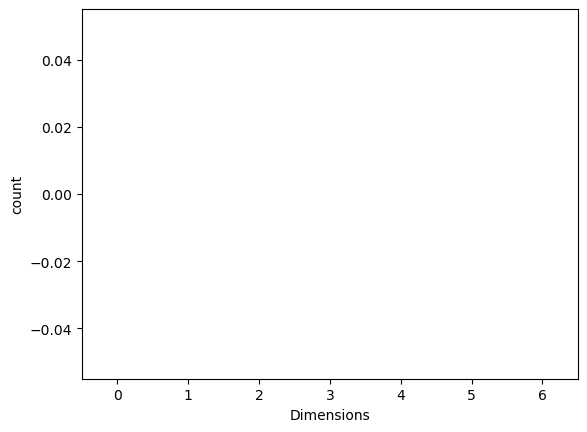

In [31]:
sb.countplot(x= 'Dimensions', data= df)

plt.show()

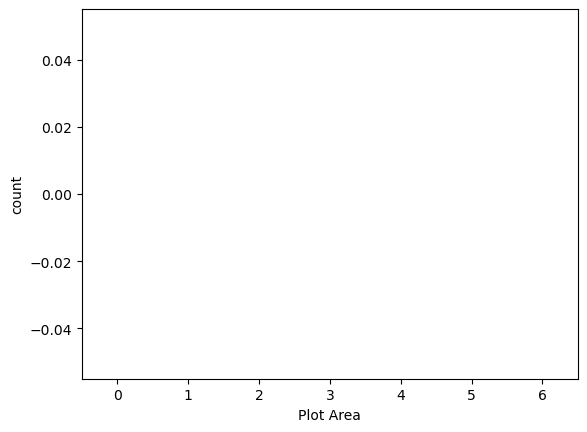

In [32]:
sb.countplot(x= 'Plot Area', data= df)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [33]:
drop_cols = ['Dimensions', 'Plot Area', 'Index', 'Title', 'Description', 'Amount(in rupees)', 
             'location', 'Society', 'Super Area', 'overlooking', 'facing', 'Floor']

# Langsung masukkan list ke dalam columns, Pandas akan otomatis menyaringnya
df.drop(columns=drop_cols, errors='ignore', inplace=True)

In [34]:
df.dropna(subset=['Price (in rupees)'], inplace=True)

In [35]:
for col in ['Carpet Area', 'Bathroom', 'Balcony']:
    if col in df.columns:
        # Mengambil karakter angka saja dari string
        df[col] = df[col].astype(str).str.extract(r'(\d+)').astype(float)

In [36]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Price (in rupees)')
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_1684\156533879.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [37]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col].fillna('Unknown', inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_1684\3051039609.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [38]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype='uint8')

In [39]:
X = df_encoded.drop(columns=['Price (in rupees)'])
y = df_encoded['Price (in rupees)'].values

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

In [41]:
all_data = np.hstack((X_scaled, y.reshape(-1, 1)))
all_columns = list(X.columns) + ['target_price']

# 10. Buat DataFrame Baru
df_clean = pd.DataFrame(all_data, columns=all_columns)

In [44]:
import time
print("Menyimpan ke CSV yang sudah dirampingkan...")
start_time = time.time()

# Kita simpan langsung ke folder tujuan submission Anda
df_clean.to_csv('house_prices/clean_data.csv', index=False)

Menyimpan ke CSV yang sudah dirampingkan...


In [45]:
print(f"⏱️ Selesai! Waktu menulis CSV baru: {time.time() - start_time:.2f} detik")

⏱️ Selesai! Waktu menulis CSV baru: 979.79 detik
